In [10]:
from qiskit import *
from qiskit.quantum_info import Operator
from qiskit_aer import *

In [11]:
def ring_entanglement(n : int):
    qc = QuantumCircuit(n);
    #qc.h(0);
    for i in range(n):
        qc.h(i);
    for i in range(n - 1):
        qc.cz(i, i + 1);
    if n >= 1:
        qc.cz(n - 1, 0)
    qc.measure_all();
    return qc;

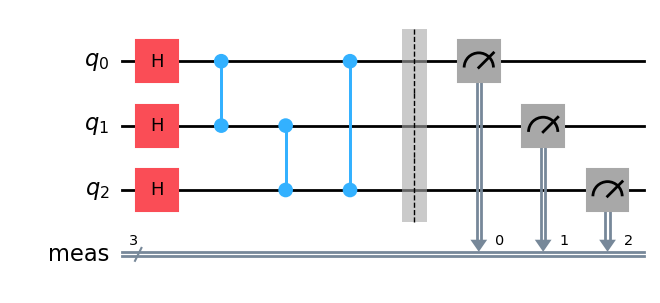

In [12]:
qc = ring_entanglement(3);
qc.draw('mpl')

In [13]:
sim = AerSimulator(method = 'statevector');
cc = transpile(qc, sim);

In [14]:
res = sim.run(cc, shots = 4096).result();
counts = res.get_counts(cc);

In [15]:
counts

{'111': 524,
 '011': 537,
 '001': 507,
 '110': 450,
 '100': 491,
 '000': 539,
 '010': 520,
 '101': 528}